# Combined logoplots for Suptavumab-IgG and Suptavumab-Fab

This notebook generates vertically stacked logo plots with aligned x-axes for both antibody formats.
Uses identical parameters from the individual suptavumab notebook for both IgG and Fab.

Import Python modules:

In [1]:
import functools
import itertools
import operator
import os
import re

import altair as alt
import dmslogo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_ = alt.data_transformers.disable_max_rows()

# Configure matplotlib for editable SVG text
plt.rcParams['svg.fonttype'] = 'none'  # Ensure text is saved as text, not paths

Set CSV paths and per-antibody configuration:

In [2]:
# Per-antibody configuration (identical parameters for both IgG and Fab)
antibody_configs = {
    "Suptavumab-IgG": {
        "escape_csv": "../../../results/antibody_escape/averages/Suptavumab-IgG_mut_effect.csv",
        "phenotypes_csv": "../../../results/func_effects/averages/293T-TIM1_entry_func_effects.csv",
        "min_cell_entry": -2.5,
        "max_escape_std": 1.25,
        "highlight_params": {
            "n_site_escape": 2,
            "n_top_mut_escape": 8,
            "min_site_escape": 5,
            "min_top_mut_escape": 1.62,
        },
    },
    "Suptavumab-Fab": {
        "escape_csv": "../../../results/antibody_escape/averages/Suptavumab-Fab_mut_effect.csv",
        "phenotypes_csv": "../../../results/func_effects/averages/293T-TIM1_entry_func_effects.csv",
        "min_cell_entry": -2.5,
        "max_escape_std": 1,
        "highlight_params": {
            "n_site_escape": 2,
            "n_top_mut_escape": 8,
            "min_site_escape": 8,
            "min_top_mut_escape": 1.62,
        },
    },
}

# Shared configuration
positive_escape_only = True
drop_low_cell_entry = True
exclude_zero_escape_std = True

aas = list(dmslogo.colorschemes.AA_CHARGE)
lineplot_xticks = [0, 100, 200, 300, 400]

sites_no_highlight = {}
file_extensions = [".svg", ".pdf"]
logoplot_subdir = "../output"

# Create output dir
os.makedirs(logoplot_subdir, exist_ok=True)

Load and process data for both antibodies with their specific parameters:

In [3]:
# Helper function to harmonize column names
def choose_first_present(df, candidates, new_name):
    for c in candidates:
        if c in df.columns:
            df = df.rename(columns={c: new_name})
            return df, c
    raise KeyError(f"None of the candidate columns {candidates} found in dataframe.")

# Load escape data for both antibodies with per-antibody parameters
escape_dfs = []

for antibody_name, config in antibody_configs.items():
    print(f"\n{'='*60}")
    print(f"Loading {antibody_name}")
    print(f"{'='*60}")
    
    escape_csv = config["escape_csv"]
    phenotypes_csv = config["phenotypes_csv"]
    min_cell_entry = config["min_cell_entry"]
    max_escape_std = config["max_escape_std"]
    
    # Load phenotypes for this antibody
    pheno = pd.read_csv(phenotypes_csv)
    pheno, used_cell_entry_col = choose_first_present(
        pheno,
        ["cell entry", "cell_entry", "effect"],
        "cell entry"
    )
    pheno = pheno[["site", "wildtype", "mutant", "cell entry"]]
    print(f"Phenotypes from {phenotypes_csv} using column '{used_cell_entry_col}'")
    
    # Load escape data
    escape_raw = pd.read_csv(escape_csv)
    
    # Standardize escape column
    escape_raw, used_escape_col = choose_first_present(
        escape_raw,
        ["escape_mean", "escape_median", "escape"],
        "escape"
    )
    
    # Ensure escape_std is numeric
    if "escape_std" in escape_raw.columns:
        escape_raw["escape_std"] = pd.to_numeric(escape_raw["escape_std"], errors="coerce")
    else:
        escape_raw["escape_std"] = np.nan
    
    # Filter by escape_std (antibody-specific max_escape_std)
    before = len(escape_raw)
    mask = escape_raw["escape_std"].notna()
    if exclude_zero_escape_std:
        mask &= ~np.isclose(escape_raw["escape_std"], 0)
    if max_escape_std is not None:
        mask &= (escape_raw["escape_std"] <= max_escape_std)
    
    # If escape_std is all NaN, keep all rows
    if mask.sum() == 0 and escape_raw["escape_std"].isna().all():
        mask = np.ones(len(escape_raw), dtype=bool)
    
    escape_raw = escape_raw.loc[mask].copy()
    print(f"Dropped {before - mask.sum()} rows using escape_std filter (max={max_escape_std})")
    print(f"Used '{used_escape_col}' for escape")
    
    # Add antibody column
    escape_raw["antibody"] = antibody_name
    
    # Merge with phenotypes
    escape_ab = (
        escape_raw[["antibody", "site", "wildtype", "mutant", "escape"]]
        .merge(
            pheno,
            on=["site", "wildtype", "mutant"],
            how="left",
            validate="many_to_one",
        )
        .query("mutant in @aas")
    )
    
    # Apply cell entry filtering (antibody-specific min_cell_entry)
    if drop_low_cell_entry:
        escape_ab["escape"] = escape_ab["escape"].where(
            escape_ab["cell entry"] >= min_cell_entry, 0
        )
    
    escape_ab["cell entry"] = escape_ab["cell entry"].fillna(0).clip(lower=min_cell_entry)
    
    if positive_escape_only:
        escape_ab["escape"] = escape_ab["escape"].clip(lower=0)
    
    print(f"Final rows for {antibody_name}: {len(escape_ab)}")
    
    escape_dfs.append(escape_ab)

# Combine both antibodies
escape = pd.concat(escape_dfs, ignore_index=True)

antibodies = escape["antibody"].unique().tolist()
print(f"\n{'='*60}")
print(f"Combined {len(antibodies)} antibodies: {antibodies}")
print(f"{'='*60}")

# Fill missing combinations with zero for plotting
escape_fill_zero = (
    pd.DataFrame(
        [[*tup, 0] for tup in itertools.product(escape["site"].unique(), aas, antibodies)],
        columns=["site", "mutant", "antibody", "escape"]
    )
    .merge(
        escape[["site", "wildtype"]].drop_duplicates(),
        on="site",
        validate="many_to_one",
    )
)

# Merge real + fill-in-zero escape data
escape = (
    escape[["site", "mutant", "antibody", "cell entry", "escape"]]
    .merge(
        escape_fill_zero,
        on=["site", "mutant", "antibody"],
        how="outer",
        validate="one_to_one",
    )
    .assign(
        **{
            "cell entry": lambda x: x["cell entry"].fillna(0),
            "escape": lambda x: x["escape_x"].where(x["escape_x"].notnull(), x["escape_y"]),
        }
    )
    .drop(columns=["escape_x", "escape_y"])
)

print(f"\nFinal combined escape dataframe: {len(escape)} rows")


Loading Suptavumab-IgG
Phenotypes from ../../../results/func_effects/averages/293T-TIM1_entry_func_effects.csv using column 'effect'
Dropped 1037 rows using escape_std filter (max=1.25)
Used 'escape_mean' for escape
Final rows for Suptavumab-IgG: 8497

Loading Suptavumab-Fab
Phenotypes from ../../../results/func_effects/averages/293T-TIM1_entry_func_effects.csv using column 'effect'
Dropped 2106 rows using escape_std filter (max=1)
Used 'escape_mean' for escape
Final rows for Suptavumab-Fab: 7359

Combined 2 antibodies: ['Suptavumab-IgG', 'Suptavumab-Fab']

Final combined escape dataframe: 20160 rows


Identify sites to highlight based on escape magnitude (using antibody-specific parameters):

In [4]:
# Get total and top magnitude escape at each site
per_site_escape = (
    escape
    .groupby(["antibody", "site"], as_index=False)
    .aggregate(
        site_escape=pd.NamedAgg("escape", lambda s: s.abs().sum()),
        top_mut_escape=pd.NamedAgg("escape", lambda s: s.abs().max()),
    )
    .melt(id_vars=["antibody", "site"], var_name="escape_type", value_name="escape")
    .assign(
        rank=lambda x: (
            x.groupby(["antibody", "escape_type"])["escape"].rank(
                method="min", ascending=False
            ).astype(int)
        )
    )
    .merge(
        (
            pd.DataFrame(sites_no_highlight.items(), columns=["antibody", "site"])
            .explode("site")
            .assign(manual_no_highlight=True)
        ),
        on=["antibody", "site"],
        validate="many_to_one",
        how="left",
    )
    .assign(manual_no_highlight=lambda x: x["manual_no_highlight"].fillna(False).astype(bool))
)

/tmp/ipykernel_27686/4037978917.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .assign(manual_no_highlight=lambda x: x["manual_no_highlight"].fillna(False).astype(bool))


In [5]:
# Apply antibody-specific highlighting logic
highlight_masks = []

for antibody_name, config in antibody_configs.items():
    highlight_params = config["highlight_params"]
    
    ab_mask = per_site_escape["antibody"] == antibody_name
    
    # site_escape: OR logic
    site_escape_condition = (
        ab_mask
        & (per_site_escape["escape_type"] == "site_escape")
        & (
            (per_site_escape["escape"] >= highlight_params["min_site_escape"])
            | (per_site_escape["rank"] <= highlight_params["n_site_escape"])
        )
    )
    
    # top_mut_escape: AND logic
    top_mut_condition = (
        ab_mask
        & (per_site_escape["escape_type"] == "top_mut_escape")
        & (
            (per_site_escape["escape"] >= highlight_params["min_top_mut_escape"])
            & (per_site_escape["rank"] <= highlight_params["n_top_mut_escape"])
        )
    )
    
    highlight_masks.append(site_escape_condition | top_mut_condition)

# Combine all antibody-specific masks
per_site_escape["highlight"] = (
    ~per_site_escape["manual_no_highlight"]
    & functools.reduce(operator.or_, highlight_masks)
)

# Print summary
print("Number of sites to highlight for each antibody:")
display(
    per_site_escape.query("highlight").groupby("antibody").aggregate(
        n_sites_to_highlight=pd.NamedAgg("site", "nunique")
    )
)

Number of sites to highlight for each antibody:


,n_sites_to_highlight
antibody,
Suptavumab-Fab,7
Suptavumab-IgG,2


In [6]:
# Visualize site selection
site_selection = alt.selection_point(fields=["site"], on="mouseover", empty=False) 

per_site_escape_chart = (
    alt.Chart(per_site_escape)
    .add_params(site_selection)
    .transform_calculate(jitter="random() - 0.5")
    .encode(
        alt.X("escape", title=None),
        alt.Y("antibody"),
        alt.YOffset("jitter:Q", scale=alt.Scale(domain=[-1.2, 1.2])),
        alt.Column(
            "escape_type",
            title=None,
            header=alt.Header(orient="bottom", labelFontSize=11, labelFontStyle="bold"),
        ),
        alt.Color("highlight", title="site to highlight"),
        tooltip=["site", "rank", "antibody", "manual_no_highlight"],
        strokeWidth=alt.condition(site_selection, alt.value(3), alt.value(0.25)),
    )
    .mark_circle(size=40, strokeOpacity=1, fillOpacity=0.4, stroke="black")
    .resolve_scale(x="independent")
    .properties(width=275, height=alt.Step(30))
    .configure_axis(grid=False)
)

per_site_escape_chart

alt.Chart(...)

Add highlighting information and compute positive/negative escape at each site:

In [7]:
escape = (
    escape
    .assign(
        positive_site_escape=(
            lambda x: (
                x.groupby(["antibody", "site"])["escape"].transform(lambda s: s[s > 0].sum())
            )
        ),
        negative_site_escape=(
            lambda x: (
                x.groupby(["antibody", "site"])["escape"].transform(lambda s: s[s < 0].sum())
            )
        ),
    )
    .drop(columns="highlight", errors="ignore")
    .merge(
        per_site_escape.groupby(["antibody", "site"], as_index=False).aggregate(
            {"highlight": "any"}
        ),
        on=["antibody", "site"],
        validate="many_to_one",
    )
)

Create color scale to color logos by cell entry effect:

In [8]:
escape["cell entry"].describe()

count    20160.000000
mean        -1.226622
std          1.170393
min         -2.500000
25%         -2.500000
50%         -1.183000
75%          0.000000
max          1.598000
Name: cell entry, dtype: float64

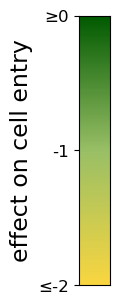

Saving to ../output/scalebar_vertical.svg
Saving to ../output/scalebar_vertical.pdf


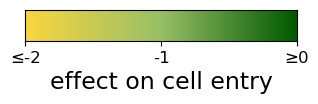

Saving to ../output/scalebar_horizontal.svg
Saving to ../output/scalebar_horizontal.pdf


In [9]:
from matplotlib.colors import LinearSegmentedColormap

min_cell_entry_colormap = -2
max_cell_entry_colormap = 0

# Warm gold-to-green palette (consistent with Nirsevimab)
colormap = dmslogo.colorschemes.ValueToColorMap(
    minvalue=min_cell_entry_colormap,
    maxvalue=max_cell_entry_colormap,
    cmap=LinearSegmentedColormap.from_list(
        "gold_to_green",
        [
            (0.0, (0.98, 0.84, 0.25)),   # warm gold
            (0.5, (0.60, 0.75, 0.40)),   # olive midpoint
            (1.0, (0.0, 0.35, 0.0)),     # deep green
        ],
        N=256
    )
)

# Generate and save scale bars
for orientation in ["vertical", "horizontal"]:
    assert colormap.minvalue == int(colormap.minvalue), "code requires integer minvalue for color scale"
    assert colormap.maxvalue == int(colormap.maxvalue), "code requires integer maxvalue for color scale"

    scale_fig, scale_ax = colormap.scale_bar(
        orientation=orientation,
        label="effect on cell entry",
    )

    ticks = list(range(int(colormap.minvalue), int(colormap.maxvalue) + 1))
    ticklabels = [f"≤{ticks[0]}"] + [str(t) for t in ticks[1:-1]] + [f"≥{ticks[-1]}"]
    ax = scale_ax.xaxis if orientation == "horizontal" else scale_ax.yaxis
    ax.set_ticks(ticks)
    ax.set_ticklabels(ticklabels)

    display(scale_fig)

    for ext in file_extensions:
        fname = os.path.join(logoplot_subdir, f"scalebar_{orientation}{ext}")
        print(f"Saving to {fname}")
        scale_fig.savefig(fname)

    plt.close(scale_fig)

# Apply the color mapping
escape["letter_color"] = colormap.val_to_color(
    escape["cell entry"].clip(lower=min_cell_entry_colormap, upper=max_cell_entry_colormap)
)

Generate combined vertically stacked plot for both antibodies with aligned x-axis:

Making combined plot for ['Suptavumab-IgG', 'Suptavumab-Fab']


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/dmslogo/facet.py:131: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([gridrow_col, gridcol_col])
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/dmslogo/facet.py:203: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (row, _), idata in name_d["data"].groupby([gridrow_col, gridcol_col]):
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/dmslogo/facet.py:443: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version

Saving to ../output/Suptavumab_IgG_and_Fab_combined.svg
Saving to ../output/Suptavumab_IgG_and_Fab_combined.pdf


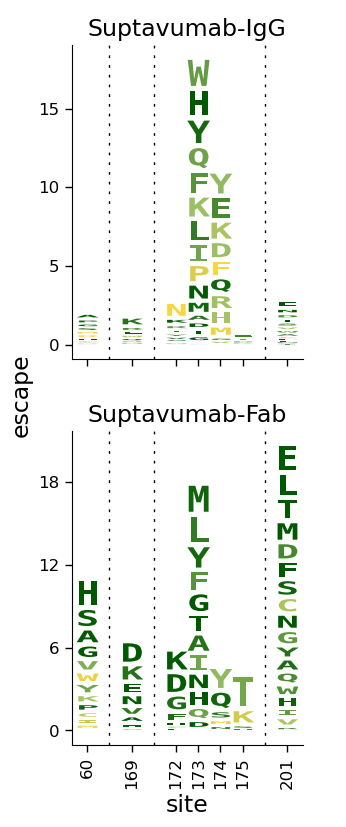

In [10]:
import matplotlib.patches as mpatches

# Prepare data for combined plot
antibodies_to_plot = ["Suptavumab-IgG", "Suptavumab-Fab"]

print(f"Making combined plot for {antibodies_to_plot}")

# Set antibody as categorical with desired order to control plotting order
df = (
    escape
    .query("antibody in @antibodies_to_plot")
    .assign(
        antibody=lambda x: pd.Categorical(x["antibody"], categories=antibodies_to_plot, ordered=True),
        highlight=lambda x: x.groupby("site")["highlight"].transform("any")
    )
    .sort_values("antibody")  # Ensure correct order
)

# Create combined facet plot with both antibodies stacked vertically (logos only)
fig, axes = dmslogo.facet_plot(
    df,
    x_col="site",
    show_col="highlight",
    gridrow_col="antibody",  # Stack by antibody
    draw_line_kwargs=None,  # No line plots
    draw_logo_kwargs={
        "letter_col": "mutant",
        "letter_height_col": "escape",
        "xtick_col": "site",
        "color_col": "letter_color",
        "widthscale": 0.6,  # Use full width since no line plots
    },
    share_xlabel=True,
    share_ylabel=True,
    height_per_ax=3.5,
    wspace=0.6,
    share_ylim_across_rows=False,
)

# ---- Add a very light outline to the letters (works regardless of dmslogo version) ----
# linewidth is in points in matplotlib; 0.2 is subtle but visible in PDF/SVG
outline_lw = 0.2
outline_color = "white"   # try "#F2F2F2" for slightly softer; avoid black unless you really want it

# With only logos, axes is 1D or (n_rows, 1)
if axes.ndim == 1:
    # 1D array of axes (one per antibody)
    for logo_ax in axes:
        for p in logo_ax.patches:
            # dmslogo letters are PathPatches; ignore other patch types if present
            if isinstance(p, mpatches.PathPatch):
                p.set_edgecolor(outline_color)
                p.set_linewidth(outline_lw)
                p.set_joinstyle("round")   # smoother corners
                p.set_capstyle("round")    # smoother ends
else:
    # 2D array (should be shape (n_rows, 1))
    for i in range(axes.shape[0]):
        logo_ax = axes[i, 0]
        for p in logo_ax.patches:
            if isinstance(p, mpatches.PathPatch):
                p.set_edgecolor(outline_color)
                p.set_linewidth(outline_lw)
                p.set_joinstyle("round")
                p.set_capstyle("round")

# Save combined plot
for ext in file_extensions:
    fname = os.path.join(logoplot_subdir, f"Suptavumab_IgG_and_Fab_combined{ext}")
    print(f"Saving to {fname}")
    fig.savefig(fname, bbox_inches="tight")

display(fig)
plt.close(fig)

Export highlighted mutations shown in the logo:

In [11]:
# Get highlighted sites summary
highlighted_sites_summary = (
    per_site_escape.query("highlight")
    .pivot_table(index=["antibody", "site"], columns="escape_type", values="escape")
    .reset_index()
    .rename(columns={"site_escape": "site_escape_sum", "top_mut_escape": "site_escape_max"})
)

# Set escape threshold for logo display
escape_threshold = 0.1

# Extract mutations shown in logo (highlighted sites, escape > threshold)
mutations_in_logo = (
    escape.merge(highlighted_sites_summary, on=["antibody", "site"], how="inner")
    .query(f"escape > {escape_threshold}")
    .loc[:, ["antibody", "site", "wildtype", "mutant", "escape", "cell entry"]]
    .sort_values(["antibody", "site", "escape"], ascending=[True, True, False])
    .drop_duplicates()
    .reset_index(drop=True)
)

out_csv = os.path.join(logoplot_subdir, "Suptavumab_IgG_and_Fab_mutations_shown_in_logo.csv")
mutations_in_logo.to_csv(out_csv, index=False)
print(f"✅ Saved {len(mutations_in_logo)} mutations to {out_csv}")
display(mutations_in_logo.head(20))

✅ Saved 90 mutations to ../output/Suptavumab_IgG_and_Fab_mutations_shown_in_logo.csv


,antibody,site,wildtype,mutant,escape,cell entry
0,Suptavumab-Fab,60,E,H,2.1370,0.05500
1,Suptavumab-Fab,60,E,S,1.5050,-0.05713
2,Suptavumab-Fab,60,E,A,1.1560,-0.02277
3,Suptavumab-Fab,60,E,G,1.0640,0.58170
4,Suptavumab-Fab,60,E,V,0.8941,-0.82960
5,Suptavumab-Fab,60,E,W,0.8319,-1.86700
6,Suptavumab-Fab,60,E,Y,0.8173,-0.73850
7,Suptavumab-Fab,60,E,K,0.6531,-1.15500
8,Suptavumab-Fab,60,E,P,0.5916,-0.11460
9,Suptavumab-Fab,60,E,C,0.5108,-1.38800


Show summary of why each site was highlighted:

In [12]:
def explain_highlight_reasons(per_site_escape, antibody_configs):
    reasons = []

    for idx, row in per_site_escape.iterrows():
        if not row["highlight"]:
            continue

        antibody = row["antibody"]
        site = row["site"]
        escape_type = row["escape_type"]
        escape_val = row["escape"]
        rank = row["rank"]
        
        # Get antibody-specific params
        highlight_params = antibody_configs[antibody]["highlight_params"]

        site_reasons = []

        if escape_type == "site_escape":
            if escape_val >= highlight_params["min_site_escape"]:
                site_reasons.append(f"site_escape ≥ {highlight_params['min_site_escape']} ({escape_val:.2f})")
            if rank <= highlight_params["n_site_escape"]:
                site_reasons.append(f"rank ≤ {highlight_params['n_site_escape']} for site_escape (rank={rank})")

        if escape_type == "top_mut_escape":
            if escape_val >= highlight_params["min_top_mut_escape"]:
                site_reasons.append(f"top_mut_escape ≥ {highlight_params['min_top_mut_escape']} ({escape_val:.2f})")
            if rank <= highlight_params["n_top_mut_escape"]:
                site_reasons.append(f"rank ≤ {highlight_params['n_top_mut_escape']} for top_mut_escape (rank={rank})")

        if site_reasons:
            reasons.append({
                "antibody": antibody,
                "site": site,
                "escape_type": escape_type,
                "escape_value": escape_val,
                "rank": rank,
                "reason": "; ".join(site_reasons)
            })

    return pd.DataFrame(reasons)

highlight_explanations = explain_highlight_reasons(per_site_escape, antibody_configs)
display(highlight_explanations.sort_values(["antibody", "site"]))

,antibody,site,escape_type,escape_value,rank,reason
0,Suptavumab-Fab,60,site_escape,10.89650,3,site_escape ≥ 8 (10.90)
5,Suptavumab-Fab,60,top_mut_escape,2.13700,4,top_mut_escape ≥ 1.62 (2.14); rank ≤ 8 for top...
6,Suptavumab-Fab,169,top_mut_escape,1.67800,6,top_mut_escape ≥ 1.62 (1.68); rank ≤ 8 for top...
7,Suptavumab-Fab,172,top_mut_escape,1.63200,7,top_mut_escape ≥ 1.62 (1.63); rank ≤ 8 for top...
1,Suptavumab-Fab,173,site_escape,17.75880,2,site_escape ≥ 8 (17.76); rank ≤ 2 for site_esc...
8,Suptavumab-Fab,173,top_mut_escape,2.27000,2,top_mut_escape ≥ 1.62 (2.27); rank ≤ 8 for top...
9,Suptavumab-Fab,174,top_mut_escape,1.72200,5,top_mut_escape ≥ 1.62 (1.72); rank ≤ 8 for top...
10,Suptavumab-Fab,175,top_mut_escape,2.51900,1,top_mut_escape ≥ 1.62 (2.52); rank ≤ 8 for top...
2,Suptavumab-Fab,201,site_escape,20.65440,1,site_escape ≥ 8 (20.65); rank ≤ 2 for site_esc...
11,Suptavumab-Fab,201,top_mut_escape,2.14200,3,top_mut_escape ≥ 1.62 (2.14); rank ≤ 8 for top...
